In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mijuu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("../data/newsData/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Descriptive Statistics

In [4]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

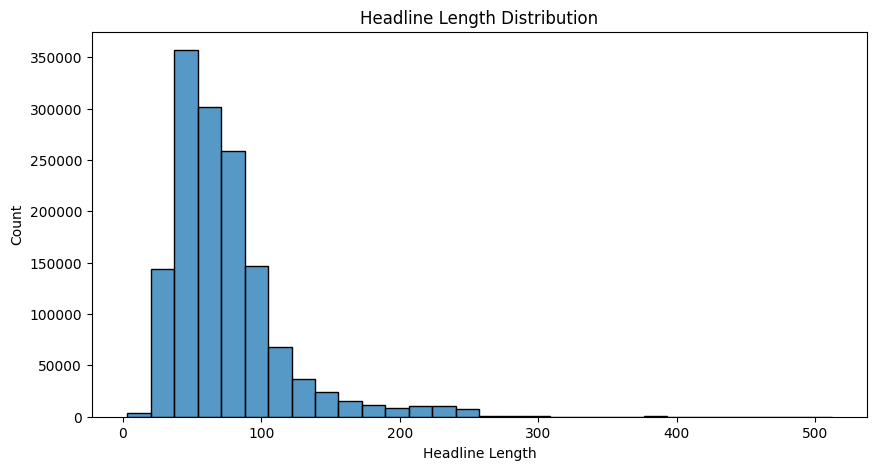

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=30)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.show()

Most headlines are short and concise
Few extremely long headlines exist

In [6]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

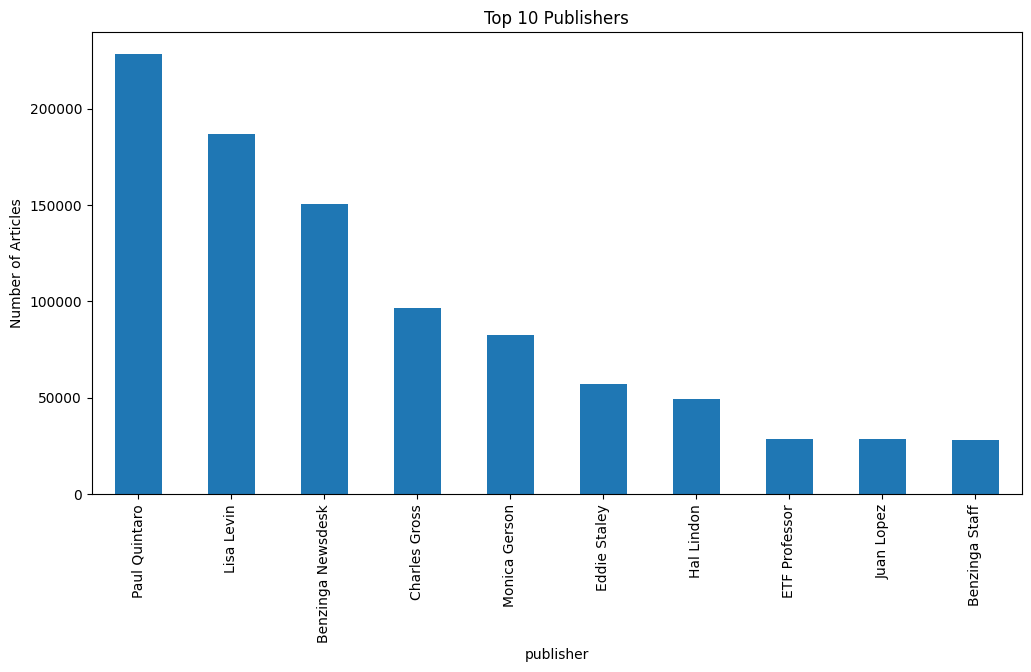

In [7]:
plt.figure(figsize=(12,6))
publisher_counts.head(10).plot(kind='bar')

plt.title("Top 10 Publishers")
plt.ylabel("Number of Articles")
plt.show()

Date & Time Analysis

In [12]:
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

In [13]:
daily_news = df.groupby(df['date'].dt.date).size()

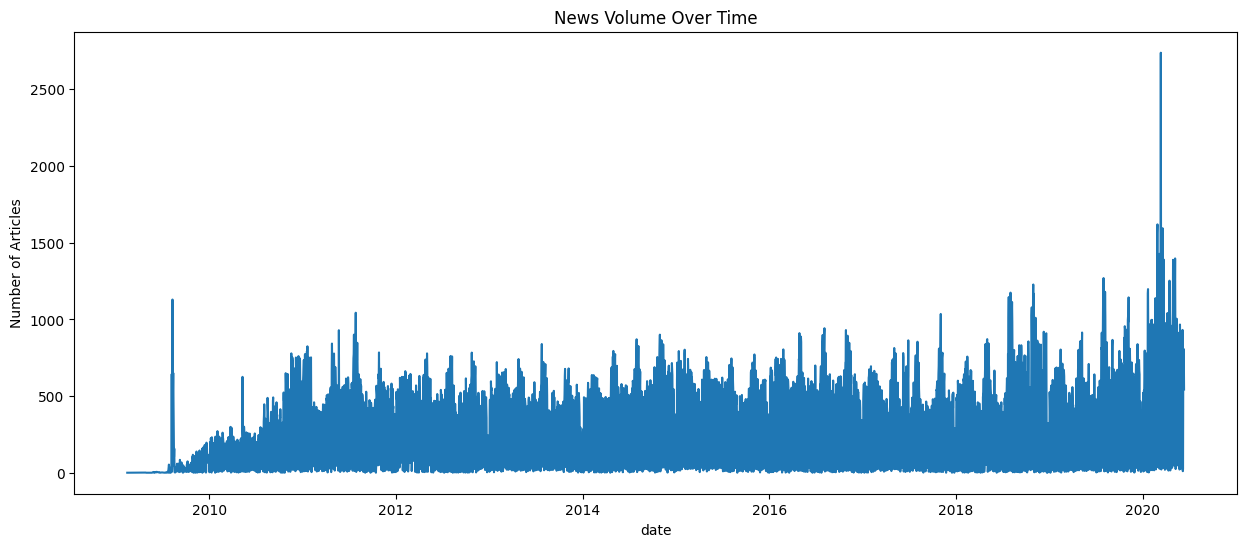

In [14]:
plt.figure(figsize=(15,6))
daily_news.plot()

plt.title("News Volume Over Time")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)

plt.title("Publishing Time Distribution")
plt.show()

Text Cleaning

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_headline'] = df['headline'].astype(str).apply(clean_text)

Keyword Analysis (CountVectorizer)

In [17]:
vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(df['clean_headline'])

word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(by='count', ascending=False)

word_counts

,word,count
18,vs,162147
14,stocks,161868
6,est,140606
5,eps,128929
13,shares,114209
11,reports,108707
17,update,91680
7,market,90880
4,earnings,87185
12,sales,79526


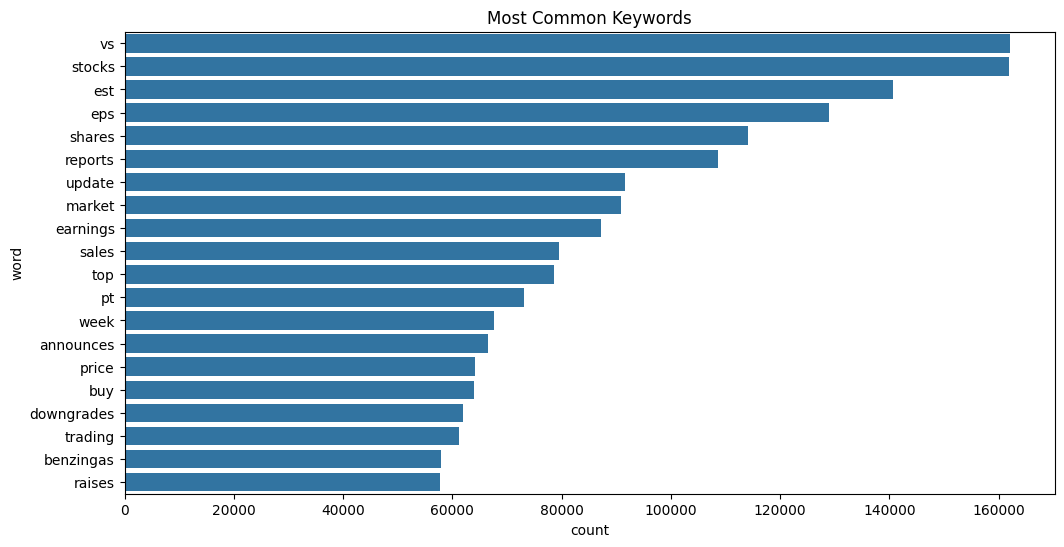

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='word',
    data=word_counts
)

plt.title("Most Common Keywords")
plt.show()

TF-IDF Analysis

In [19]:
tfidf = TfidfVectorizer(max_features=20)

X_tfidf = tfidf.fit_transform(df['clean_headline'])

tfidf_words = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'score': X_tfidf.toarray().sum(axis=0)
})

tfidf_words.sort_values(by='score', ascending=False)

,word,score
14,stocks,127739.546662
13,shares,78948.302179
4,earnings,75297.188420
7,market,67142.634411
17,update,66698.281087
18,vs,65487.899683
11,reports,64115.106868
5,eps,60899.669076
0,announces,55893.949971
15,top,55508.584729


Word Cloud Visualization

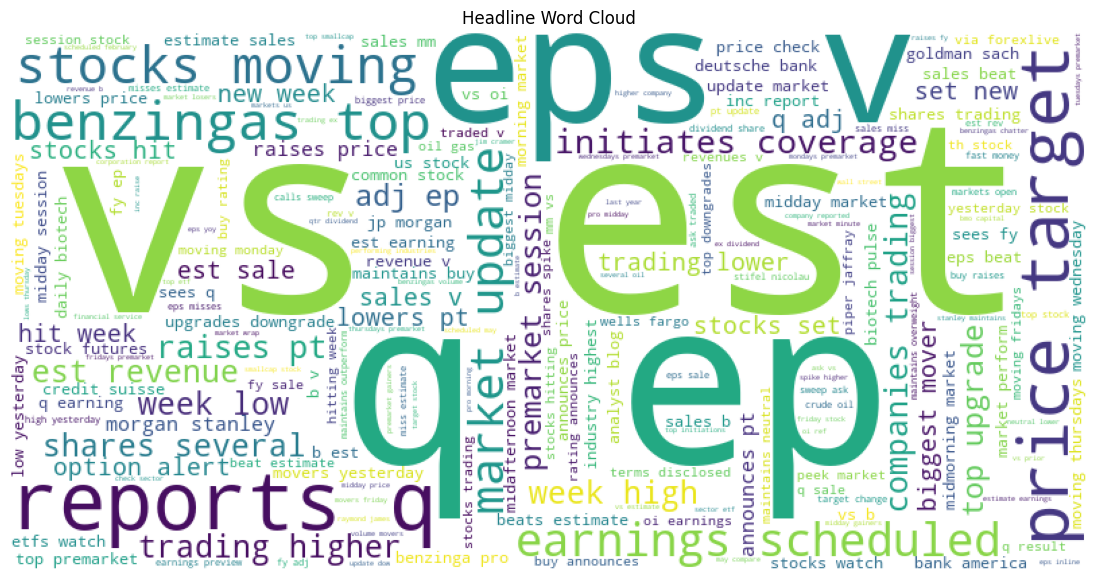

In [20]:
text = " ".join(df['clean_headline'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Headline Word Cloud")
plt.show()

In [21]:
df['domain'] = df['publisher'].str.extract(r'@([\w.-]+)')

df['domain'].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64